# Raconteur ingestion health -- is the Synology edge feed arriving?

Raconteur (`raconteur.ad.local.symmatree.com`, a Synology NAS) runs an **edge Grafana
Alloy** container that ships host metrics + hardware (SNMP) metrics + logs to the **tiles**
prod cluster over OTLP. Unlike the component notebooks (mimir/loki/alloy assess a deployed
component), this is a **special-collection** notebook: it assesses whether an *edge push
source* is actually delivering -- fresh and complete -- against Mimir and Loki.

It does **not** assume the edge source is up (that is the thing under test); it **does**
assume Mimir and Loki work (if they do not, use the mimir/loki notebooks first). A
load-bearing **empty result is a suspected edge outage, not "healthy"** -- the summary
treats silent-empty as a finding, never a false green.

Three independent views, so a disagreement localizes the fault:
- **Metrics** (Mimir): unix/node_exporter + SNMP series present and fresh.
- **Logs** (Loki): `host="raconteur"` synology streams present and recent (some are legitimately sparse).
- **Blackbox probe** (Mimir): the `raconteur-syno-ui` Probe (`probe_success`) -- is the NAS itself reachable?

Edge labels and background: [docs/synology-monitoring.md](../docs/synology-monitoring.md).
Head-end OTLP receiver these feed: [alloy-health.ipynb](alloy-health.ipynb) ([#651](https://github.com/symmatree/tiles/issues/651)).
Design: [tiles#652](https://github.com/symmatree/tiles/issues/652) (parent [#644](https://github.com/symmatree/tiles/issues/644)),
[docs/notebooks.md](../docs/notebooks.md).

Run from `notebooks/`: `jupyter nbconvert --to notebook --execute --inplace raconteur-ingest.ipynb`

In [1]:
mimir_url = "http://mimir-gateway.mimir.svc"   # edge metrics land in Mimir (unix + SNMP)
loki_url = "http://loki.loki.svc:3100"         # edge logs land in Loki (host="raconteur")
tenant = "tiles"          # X-Scope-OrgID for Mimir and Loki (the OTLP org)
edge_cluster = "bond"     # OTLP attributes.cluster on the edge metrics (NOT the Loki tenant label)
edge_instance = "raconteur"
lookback_hours = 24
range_step_s = 300
metric_stale_s = 900      # chosen (no mixin): unix/SNMP are fixed-interval scrapes, so
                          # staleness beyond this = edge Alloy or OTLP metrics path down
log_stale_s = 3600        # chosen (no mixin): synology-syslog/synolog tick at least hourly;
                          # auth/daemon are legitimately sparse -- see per-stream breakdown
log_sample_lines = 100
capture_file = ""         # replay a prior raw capture JSON instead of querying live
output_dir = ""           # if set: write raw capture + agent stats there
debug = False

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path
import nb_capture as nbc

plt.rcParams.update(nbc.MPL_STYLE)
NOTEBOOK = 'raconteur-ingest'
cap = nbc.Capture(replay_file=capture_file, mimir_url=mimir_url, loki_url=loki_url,
                  tenant=tenant, edge_cluster=edge_cluster, edge_instance=edge_instance,
                  lookback_hours=lookback_hours, range_step_s=range_step_s,
                  metric_stale_s=metric_stale_s, log_stale_s=log_stale_s,
                  log_sample_lines=log_sample_lines)
tenant = cap.meta['tenant']
edge_cluster, edge_instance = cap.meta['edge_cluster'], cap.meta['edge_instance']
lookback_hours, step = cap.meta['lookback_hours'], cap.meta['range_step_s']
METRIC_STALE_S, LOG_STALE_S = cap.meta['metric_stale_s'], cap.meta['log_stale_s']
mm = nbc.Mimir(cap, cap.meta['mimir_url'], tenant)
lk = nbc.Loki(cap, cap.meta['loki_url'], tenant)
# The synology log tailers (docs/synology-monitoring.md). Only syslog (messages) is
# reliably regular; synolog/auth/daemon are event-driven and legitimately sparse (first
# live run: synolog + daemon had 0 lines over 24h), so their silence is noted, not flagged.
# An edge log-path outage silences ALL streams -> the aggregate recent-volume check catches
# it, and syslog stalling on its own is the sentinel.
EXPECTED_LOG_JOBS = ['synology-syslog', 'synology-synolog', 'synology-auth', 'synology-daemon']
REGULAR_LOG_JOBS = ['synology-syslog']
print(f"mimir: {cap.meta['mimir_url']}  loki: {cap.meta['loki_url']}  tenant: {tenant}  "
      f"edge: cluster={edge_cluster} instance={edge_instance}  "
      f"{'REPLAY of ' + cap.run_at if cap.replay else 'live'}")

mimir: http://mimir-gateway.mimir.svc  loki: http://loki.loki.svc:3100  tenant: tiles  edge: cluster=bond instance=raconteur  live


In [3]:
# --- ASSUMPTIONS: verify the INSTRUMENTS (Mimir + Loki), not the subject ---
# The subject here is the edge feed, which we do NOT assume is up. What must hold for any
# reading to be trustworthy is that the two instruments are themselves live: Mimir is
# ingesting+serving fresh data, and Loki is serving fresh logs. If an instrument is dark,
# the notebook is unassessable (-> mimir/loki notebooks), never a false green. An empty
# EDGE result is handled in the summary as a finding, not here.
assumption_warnings = []
INSTR_STALE_S = 600

# Mimir alive: `up` is scraped cluster-wide every few seconds, so its newest sample dates
# the Mimir ingest+serve path independently of the edge.
mimir_instr_ts = nbc.val(mm.q('instr: mimir (up freshness)', 'max(timestamp(up))'))
mimir_instr_age = cap.now - mimir_instr_ts if not np.isnan(mimir_instr_ts) else np.inf
# Loki alive: newest line from a busy in-cluster namespace (its own), independent of edge.
try:
    loki_probe = lk.lines('instr: loki (loki ns logs)', '{namespace="loki"}', 1, 1)
    loki_instr_age = cap.now - loki_probe[0][0].timestamp() if loki_probe else np.inf
except Exception as e:
    loki_instr_age = np.inf
    if debug:
        print(f"loki instrument probe error: {e}")

print("=== ASSUMPTIONS (instruments) ===")
for name, age in [('mimir (up freshness)', mimir_instr_age), ('loki (loki ns logs)', loki_instr_age)]:
    status = 'MISSING' if np.isinf(age) else f"newest sample {age:.0f}s old" + (' -- STALE' if age > INSTR_STALE_S else '')
    print(f"  {name:<24} {status}")

if np.isinf(mimir_instr_age) or mimir_instr_age > INSTR_STALE_S:
    raise RuntimeError(f"unassessable: Mimir not serving fresh data ({mimir_instr_age:.0f}s) "
                       "-- see mimir-health.ipynb / mimir-nolgtm.ipynb before trusting this")
if np.isinf(loki_instr_age) or loki_instr_age > INSTR_STALE_S:
    raise RuntimeError(f"unassessable: Loki not serving fresh logs ({loki_instr_age:.0f}s) "
                       "-- see loki-health.ipynb / loki-nolgtm.ipynb before trusting this")

=== ASSUMPTIONS (instruments) ===
  mimir (up freshness)     newest sample 0s old
  loki (loki ns logs)      newest sample 2s old


In [4]:
# --- CAPTURE: fetch the complete raw observation up front (edge = subject under test) ---
# Empty/stale here is a finding, not an error: the edge is what we are testing. api_result
# raises only on a genuine query failure; an empty success (no such series) flows through.
sel_ne = f'{{cluster="{edge_cluster}", instance="{edge_instance}", job="integrations/node_exporter"}}'
sel_snmp = f'{{cluster="{edge_cluster}", job="integrations/snmp/raconteur"}}'

# METRICS (Mimir): presence, freshness, up-ness per edge job, and an up trend so gaps in
# the edge scrape over the window are visible (a flat line at 1 = continuous delivery).
# node_exporter freshness reads a real multi-label metric (node_cpu, series differ by
# cpu/mode so they survive timestamp() dropping __name__). SNMP freshness must instead read
# the single-series `up`: its metrics differ only by __name__, so timestamp() would collapse
# them to one labelset and Mimir rejects it ("same labelset"). `up` = one series per scrape
# target, so its scrape-time is a clean, collision-free freshness proxy.
edge_up = mm.q('edge_up', f'up{{cluster="{edge_cluster}"}}')
ne_count = nbc.val(mm.q('ne_series_count', f'count(node_cpu_seconds_total{sel_ne})'), 0.0)
ne_fresh_ts = nbc.val(mm.q('ne_fresh', f'max(timestamp(node_cpu_seconds_total{sel_ne}))'))
snmp_count = nbc.val(mm.q('snmp_series_count', f'count({sel_snmp})'), 0.0)
snmp_fresh_ts = nbc.val(mm.q('snmp_fresh', f'max(timestamp(up{sel_snmp}))'))
snmp_names = nbc.by(mm.q('snmp_top_names', f'topk(12, count by (__name__) ({sel_snmp}))'), '__name__')
f_edge_up = nbc.frame(mm.qr('edge_up_trend', f'sum by (job) (up{{cluster="{edge_cluster}"}})',
                            lookback_hours, step), 'job')

# LOGS (Loki): per-job 10m-bucket volume over the window, plus a wide-angle raw tail.
f_logvol = nbc.frame(lk.metric_range('log_vol_by_job',
    f'sum by (job) (count_over_time({{host="{edge_instance}"}}[10m]))', lookback_hours, 600), 'job')
syn_lines = lk.lines('syn_tail', f'{{host="{edge_instance}"}}', lookback_hours, max(log_sample_lines, 300))

# BLACKBOX PROBE (Mimir): the raconteur-syno-ui Probe -- is the NAS itself reachable?
probe_succ = mm.q('probe_success', 'probe_success{instance=~".*raconteur.*"}')
probe_code = mm.q('probe_http_status_code', 'probe_http_status_code{instance=~".*raconteur.*"}')
f_probe = nbc.frame(mm.qr('probe_trend', 'probe_success{instance=~".*raconteur.*"}',
                          lookback_hours, step), 'instance')
print(f"captured {len(cap.data['calls'])} raw calls")

captured 14 raw calls


edge scrape up-ness (cluster=bond): {'integrations/snmp/raconteur': '1/1 up', 'integrations/node_exporter': '1/1 up'}
unix/node_exporter: 64 node_cpu series, newest 11s old
snmp/raconteur:     2827 series, newest 37s old
  SNMP metric families present (top): ['diskIODevice', 'diskIONReadX', 'diskIONWrittenX', 'diskSMARTAttrCurrent', 'diskSMARTAttrId', 'diskSMARTAttrName', 'diskSMARTAttrRaw', 'diskSMARTAttrStatus', 'diskSMARTAttrThreshold', 'diskSMARTAttrWorst', 'diskSMARTInfoDevName', 'diskSMARTInfoIndex']


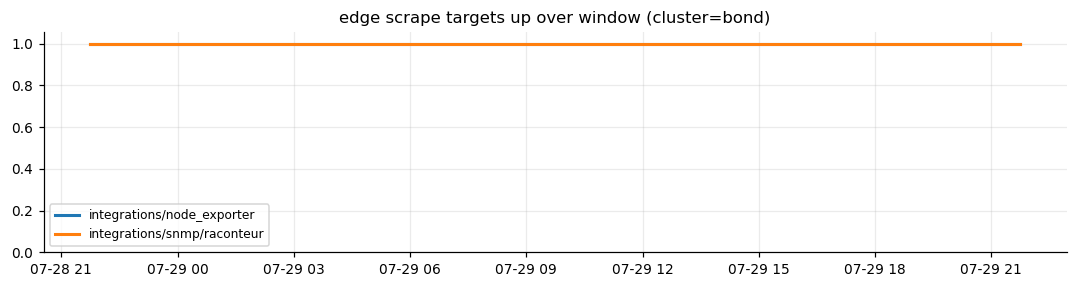

In [5]:
# --- METRICS (Mimir): unix/node_exporter + SNMP present and fresh? ---
ne_age = cap.now - ne_fresh_ts if not np.isnan(ne_fresh_ts) else np.inf
snmp_age = cap.now - snmp_fresh_ts if not np.isnan(snmp_fresh_ts) else np.inf
up_by_job = {}
for r in edge_up:
    up_by_job.setdefault(r['metric'].get('job', '?'), []).append(int(float(r['value'][1])))
up_summary = {j: f"{sum(v)}/{len(v)} up" for j, v in up_by_job.items()}

def _age(a):
    return 'MISSING' if np.isinf(a) else f"{a:.0f}s old" + (' -- STALE' if a > METRIC_STALE_S else '')

print(f"edge scrape up-ness (cluster={edge_cluster}): {up_summary or 'NO up series -- edge scraper silent'}")
print(f"unix/node_exporter: {ne_count:.0f} node_cpu series, newest {_age(ne_age)}")
print(f"snmp/raconteur:     {snmp_count:.0f} series, newest {_age(snmp_age)}")
if snmp_names:
    print(f"  SNMP metric families present (top): {sorted(snmp_names)[:12]}")

fig, ax = plt.subplots(figsize=(12, 2.6))
if f_edge_up.empty:
    ax.text(0.5, 0.5, f'no up series for cluster={edge_cluster} in window -- edge scraper was silent',
            ha='center', va='center', transform=ax.transAxes, color='C3')
    ax.grid(False)
else:
    for c in f_edge_up.columns:
        ax.plot(f_edge_up.index, f_edge_up[c], lw=2, label=c)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)
ax.set_title(f'edge scrape targets up over window (cluster={edge_cluster})')
nbc.show(fig)

synology log streams (host=raconteur), window 24h (recent = last 60m):
  synology-auth             609 lines /     42 recent
  synology-daemon             0 lines /      0 recent -- silent in window (sparse stream, may be normal)
  synology-synolog            0 lines /      0 recent -- silent in window (sparse stream, may be normal)
  synology-syslog           234 lines /      1 recent
newest synology log line overall: 3m old


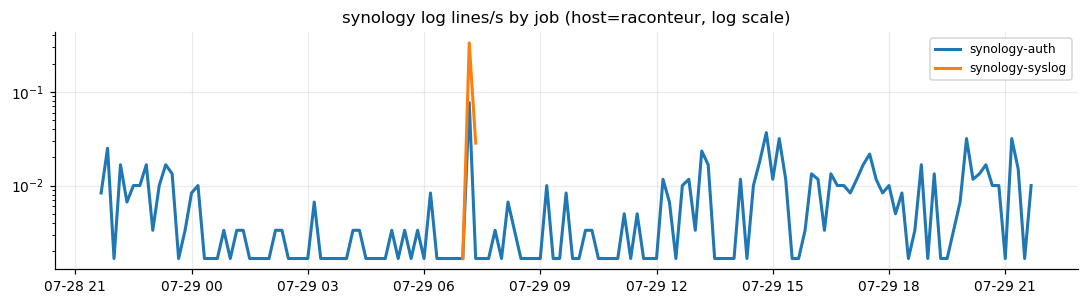


last 30 raw lines from host=raconteur, newest first:
  29 21:41:12 synology-auth        {"body":"2026-07-29T17:41:12-04:00 raconteur ssmessaged_SYNO.SurveillanceStation.Camera_8_List[27983]: APIPriority.cpp:1
  29 21:41:11 synology-auth        {"body":"2026-07-29T17:41:11-04:00 raconteur ssmessaged_SYNO.SurveillanceStation.Camera_8_List[27983]: APIPriority.cpp:1
  29 21:37:12 synology-auth        {"body":"2026-07-29T17:37:12-04:00 raconteur ssmessaged_SYNO.SurveillanceStation.Camera_8_List[8103]: SYSTEM:\tLast mess
  29 21:36:52 synology-auth        {"body":"2026-07-29T17:36:52-04:00 raconteur ssmessaged_SYNO.SurveillanceStation.Camera_8_List[27983]: APIPriority.cpp:1
  29 21:36:43 synology-auth        {"body":"2026-07-29T17:36:43-04:00 raconteur ssmessaged_SYNO.SurveillanceStation.Camera_8_List[27983]: APIPriority.cpp:1
  29 21:36:42 synology-auth        {"body":"2026-07-29T17:36:42-04:00 raconteur ssmessaged_SYNO.SurveillanceStation.Camera_8_List[27983]: APIPriority.cpp:1
  29 21:35

In [6]:
# --- LOGS (Loki): synology streams present, recent, and complete? ---
# Full-window per-job volume is the authoritative presence signal; the last-hour slice is
# the authoritative recency signal. The raw tail below is illustrative (and the wide-angle
# proof collection is alive), not load-bearing, since a 300-line tail can miss a sparse
# stream's older-but-present lines -- which the volume series still counts.
now_ts = cap.now
vol_by_job = {c: int(f_logvol[c].sum()) for c in f_logvol.columns} if not f_logvol.empty else {}
recent_buckets = max(1, int(np.ceil(LOG_STALE_S / 600)))
recent_vol_by_job = ({c: int(f_logvol[c].iloc[-recent_buckets:].sum()) for c in f_logvol.columns}
                     if not f_logvol.empty else {})
newest_by_job = {}
for ts, st, line in syn_lines:
    j = st.get('job', '?')
    newest_by_job[j] = max(newest_by_job.get(j, 0.0), ts.timestamp())
newest_any = now_ts - max(newest_by_job.values()) if newest_by_job else np.inf

all_jobs = sorted(set(list(vol_by_job) + EXPECTED_LOG_JOBS))
print(f"synology log streams (host={edge_instance}), window {lookback_hours}h "
      f"(recent = last {recent_buckets * 10}m):")
for j in all_jobs:
    vol, rvol = vol_by_job.get(j, 0), recent_vol_by_job.get(j, 0)
    if j not in EXPECTED_LOG_JOBS:
        tag = ' (unexpected job)'
    elif j in REGULAR_LOG_JOBS and rvol == 0:
        tag = ' -- STALE (regular stream, no recent lines)'
    elif vol == 0:
        tag = ' -- silent in window (sparse stream, may be normal)'
    elif rvol == 0:
        tag = ' -- quiet recently (sparse stream)'
    else:
        tag = ''
    print(f"  {j:<20} {vol:>8} lines / {rvol:>6} recent{tag}")
print(f"newest synology log line overall: "
      f"{'NONE in window -- edge log path silent' if np.isinf(newest_any) else f'{newest_any / 60:.0f}m old'}")

fig, ax = plt.subplots(figsize=(12, 2.8))
if f_logvol.empty:
    ax.text(0.5, 0.5, f'no synology logs for host={edge_instance} in window -- edge log path silent',
            ha='center', va='center', transform=ax.transAxes, color='C3')
    ax.grid(False)
else:
    for c in f_logvol.columns:
        ax.plot(f_logvol.index, f_logvol[c] / 600, lw=2, label=c)
    ax.legend(fontsize=8)
    ax.set_yscale('log')
ax.set_title(f'synology log lines/s by job (host={edge_instance}, log scale)')
nbc.show(fig)

# Wide-angle raw tail -- unfiltered proof collection is alive (authoring rule).
print(f"\nlast {min(len(syn_lines), 30)} raw lines from host={edge_instance}, newest first:")
for ts, st, line in syn_lines[:30]:
    print(f"  {ts:%d %H:%M:%S} {st.get('job', '?')[:20]:<20} {line[:120]}")

  probe https://raconteur.ad.local.symmatree.com:5001/: UP (http 200)


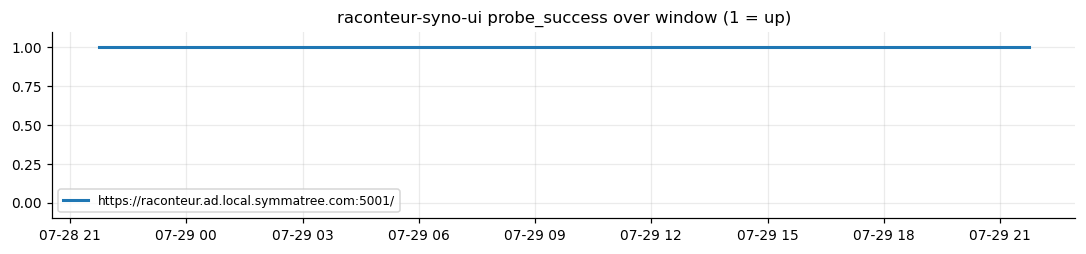

In [7]:
# --- BLACKBOX PROBE (Mimir): is the NAS itself reachable? (independent of OTLP) ---
# probe_success on the raconteur-syno-ui Probe hits the DSM UI (:5001). It is the third,
# OTLP-independent view: probe up but metrics/logs stale => the edge Alloy container / OTLP
# path is the fault, not the box; probe down + all stale => the NAS itself is unreachable.
probes = {r['metric'].get('instance', '?'): int(float(r['value'][1])) for r in probe_succ}
codes = {r['metric'].get('instance', '?'): int(float(r['value'][1])) for r in probe_code}
probe_present = bool(probes)
probe_ok = probe_present and all(v == 1 for v in probes.values())
if not probe_present:
    print("raconteur probe: NO probe_success series matched -- probe absent (this view is dark)")
else:
    for inst, ok in sorted(probes.items()):
        print(f"  probe {inst}: {'UP' if ok else 'DOWN'} (http {codes.get(inst, '?')})")

fig, ax = plt.subplots(figsize=(12, 2.2))
if f_probe.empty:
    ax.text(0.5, 0.5, 'no raconteur probe_success series in window', ha='center', va='center',
            transform=ax.transAxes, color='0.4')
    ax.grid(False)
else:
    for c in f_probe.columns:
        ax.step(f_probe.index, f_probe[c], where='post', lw=2, label=c)
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=8)
ax.set_title('raconteur-syno-ui probe_success over window (1 = up)')
nbc.show(fig)

In [8]:
# --- SUMMARY: instruments first, then the edge verdict from three independent views ---
# Silent-empty is the dominant failure mode here: a load-bearing empty EDGE result is a
# SUSPECTED OUTAGE, never "healthy". "Findings: none" is only reachable when the edge
# series were actually present and fresh.
metrics_fresh = ne_count > 0 and not np.isinf(ne_age) and ne_age <= METRIC_STALE_S
snmp_fresh = snmp_count > 0 and not np.isinf(snmp_age) and snmp_age <= METRIC_STALE_S
logs_fresh = sum(recent_vol_by_job.values()) > 0
regular_stale = [j for j in REGULAR_LOG_JOBS if recent_vol_by_job.get(j, 0) == 0]

findings = []
if not metrics_fresh:
    findings.append(f"unix/node_exporter metrics {'absent' if ne_count == 0 else f'stale ({ne_age:.0f}s)'}"
                    " -- edge Alloy scrape or OTLP metrics path down")
if not snmp_fresh:
    findings.append(f"SNMP metrics {'absent' if snmp_count == 0 else f'stale ({snmp_age:.0f}s)'}"
                    " -- SNMP exporter or edge Alloy down (SNMP-specific if unix metrics are fresh)")
if not logs_fresh:
    findings.append("no synology log lines in the recent window -- edge Alloy log path or OTLP down")
elif regular_stale:
    findings.append(f"regular log stream(s) with no recent lines: {regular_stale}")
if probe_present and not probe_ok:
    findings.append("raconteur DSM UI probe DOWN -- NAS unreachable (all edge data will go stale)")

# Cross-check localization: reconcile the three views into a one-line diagnosis.
any_telemetry = metrics_fresh or snmp_fresh or logs_fresh
if probe_ok and not any_telemetry:
    diagnosis = ("NAS reachable (probe up) but NO edge telemetry -- edge Alloy container / "
                 "OTLP path is the fault, not the box")
elif probe_present and not probe_ok and not any_telemetry:
    diagnosis = "NAS unreachable and no telemetry -- whole-box outage or network"
elif metrics_fresh and snmp_fresh and logs_fresh and (probe_ok or not probe_present):
    diagnosis = "edge delivering: unix + SNMP metrics + logs all fresh" + ("" if probe_present else " (probe view absent)")
else:
    diagnosis = "partial delivery -- see findings; the views disagree, which localizes the fault"

print("=" * 64)
print("RACONTEUR INGESTION SUMMARY")
print("=" * 64)
print(f"run:         {cap.run_at}  ({cap.mode})")
print(f"edge:        cluster={edge_cluster} instance={edge_instance}, tenant {tenant}, lookback {lookback_hours}h")
print(f"instruments: mimir {mimir_instr_age:.0f}s, loki {loki_instr_age:.0f}s (both < {INSTR_STALE_S}s)")
print()
print(f"Diagnosis: {diagnosis}")
print()
if findings:
    print("Findings:")
    for f in findings:
        print(f"  ! {f}")
else:
    print("Findings: none -- unix + SNMP metrics fresh, synology logs recent, probe up")
print()
print(f"  Metrics:  node_exporter {ne_count:.0f} series ({_age(ne_age)}); SNMP {snmp_count:.0f} series ({_age(snmp_age)})")
print(f"  Logs:     newest synology line {'-' if np.isinf(newest_any) else f'{newest_any / 60:.0f}m'} old; recent vol {recent_vol_by_job or 'none'}")
print(f"  Probe:    {('up' if probe_ok else 'DOWN') if probe_present else 'absent'}")

RACONTEUR INGESTION SUMMARY
run:         2026-07-29T21:44:32.588886+00:00  (live)
edge:        cluster=bond instance=raconteur, tenant tiles, lookback 24h
instruments: mimir 0s, loki 2s (both < 600s)

Diagnosis: edge delivering: unix + SNMP metrics + logs all fresh

Findings: none -- unix + SNMP metrics fresh, synology logs recent, probe up

  Metrics:  node_exporter 64 series (11s old); SNMP 2827 series (37s old)
  Logs:     newest synology line 3m old; recent vol {'synology-auth': 42, 'synology-syslog': 1}
  Probe:    up


In [9]:
# AGENT-READABLE STATS -- consolidated JSON; assumption status leads so a reader
# calibrates trust before any verdict, and the edge verdict is explicit booleans.
def _n(v):
    return None if v is None or (isinstance(v, float) and not np.isfinite(v)) else round(float(v), 4)

agent_stats = {
    'notebook': f'{NOTEBOOK}.ipynb',
    'run_at': cap.run_at,
    'mode': cap.mode,
    'edge': {'cluster': edge_cluster, 'instance': edge_instance, 'tenant': tenant},
    'lookback_hours': lookback_hours,
    'thresholds': {'metric_stale_s': METRIC_STALE_S, 'log_stale_s': LOG_STALE_S,
                   'instr_stale_s': INSTR_STALE_S},
    'assumptions': {'status': 'ok' if not assumption_warnings else 'degraded',
                    'warnings': assumption_warnings,
                    'instrument_age_s': {'mimir_up': _n(mimir_instr_age),
                                         'loki_logs': _n(loki_instr_age)}},
    'diagnosis': diagnosis,
    'findings': findings,
    'metrics': {'node_exporter_series': _n(ne_count), 'node_exporter_age_s': _n(ne_age),
                'snmp_series': _n(snmp_count), 'snmp_age_s': _n(snmp_age),
                'snmp_metric_families': sorted(snmp_names)[:20], 'up_by_job': up_summary},
    'logs': {'newest_line_age_s': _n(newest_any), 'volume_by_job': vol_by_job,
             'recent_volume_by_job': recent_vol_by_job, 'expected_jobs': EXPECTED_LOG_JOBS,
             'regular_stale': regular_stale},
    'probe': {'present': probe_present, 'ok': probe_ok, 'by_instance': probes,
              'http_codes': codes},
    'verdict': {'metrics_fresh': bool(metrics_fresh), 'snmp_fresh': bool(snmp_fresh),
                'logs_fresh': bool(logs_fresh)},
}
print(json.dumps(agent_stats, indent=1))

if output_dir:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)
    cap.save(out / f'{NOTEBOOK}.capture.json')
    (out / f'{NOTEBOOK}.stats.json').write_text(json.dumps(agent_stats, indent=2))
    print(f"wrote {out / f'{NOTEBOOK}.capture.json'} and {out / f'{NOTEBOOK}.stats.json'}")

{
 "notebook": "raconteur-ingest.ipynb",
 "run_at": "2026-07-29T21:44:32.588886+00:00",
 "mode": "live",
 "edge": {
  "cluster": "bond",
  "instance": "raconteur",
  "tenant": "tiles"
 },
 "lookback_hours": 24,
 "thresholds": {
  "metric_stale_s": 900,
  "log_stale_s": 3600,
  "instr_stale_s": 600
 },
 "assumptions": {
  "status": "ok",
  "warnings": [],
  "instrument_age_s": {
   "mimir_up": 0.2879,
   "loki_logs": 2.1056
  }
 },
 "diagnosis": "edge delivering: unix + SNMP metrics + logs all fresh",
 "findings": [],
 "metrics": {
  "node_exporter_series": 64.0,
  "node_exporter_age_s": 10.8509,
  "snmp_series": 2827.0,
  "snmp_age_s": 37.4919,
  "snmp_metric_families": [
   "diskIODevice",
   "diskIONReadX",
   "diskIONWrittenX",
   "diskSMARTAttrCurrent",
   "diskSMARTAttrId",
   "diskSMARTAttrName",
   "diskSMARTAttrRaw",
   "diskSMARTAttrStatus",
   "diskSMARTAttrThreshold",
   "diskSMARTAttrWorst",
   "diskSMARTInfoDevName",
   "diskSMARTInfoIndex"
  ],
  "up_by_job": {
   "integr